bash: env.sh: No such file or directory


## Description
We want to identify TFs that their activity within the differentiation trajectory of major cell type population changes in aging. 
Assuming that differentiation is a continous variable, we seek to identify TFs, which the association of their activity with trajectory changes with aging. 
- Challenge 1: how to label cells with continous value for differentiation without cell type labeling
- Challenge 2: do we have linear trajectory from naive to effector or branching: naive -> memory vs effector

- option 1: define naive markers, and select 10 choice of single cells with top quantile cells
- option 2: automated/global trajectories
    - cluster labels should be comparable between groups of samples -> to interpret what TF act change means

- protocol:
    - use only those donor-age-condition-cell type with sufficient single cell counts
    - within group and between group consideration: the association of tf activity with trajectory is within while the factor of age is between
    - probably a meta analysis to collect the evidence

In [2]:
!cd ../ && bash env.sh 
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams["font.family"] = "Arial"
main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from hiara import retrieve_feature_data, retrieve_sig_stats

from hiara import PRIOR_DIR, PLOTS_DIR, CLOCKS_DIR,  CELL_TYPES, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, AGING_COHORTS
from hiara import retrieve_adata, retrieve_net, retrieve_net_consensus
from hiara import get_config
from grn_benchmark.src.helper import load_env
env = load_env()
TASK_GRN_INFERENCE_DIR = env['TASK_GRN_INFERENCE_DIR']
to_save = f'{PLOTS_DIR}/umap/'
os.makedirs(to_save, exist_ok=True)

bash: env.sh: No such file or directory


In [39]:
resolution = 10
cell_count_t = 2
# markers = {
#     "naive": ["CCR7", "SELL", "TCF7", "LEF1", "IL7R", "LTB"],
#     "central_memory": ["CCR7", "SELL", "IL7R", "CD27", "CD28", "TCF7"],
#     "effector_memory": ["GZMK", "IFNG", "NKG7", "CCL5", "CXCR3"],
#     "effector": ["GZMB", "PRF1", "GNLY", "NKG7", "KLRG1", "ZEB2"],
#     "temra": ["GZMB", "PRF1", "GNLY", "KLRD1", "KLRG1"],
#     "exhausted": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "TOX"]
# }

markers = {
    'naive' : ["CCR7", "SELL", "TCF7", "LEF1", "LTB"],
    'memory' : ["IL7R", "CD27", "CD28", "GZMK", "CCL5"],
    'effector' : ["GZMB", "PRF1", "GNLY", "KLRG1", "KLRD1"]
}

dataset = 'op' # 'CXCL9'
cell_type = 'CD8T'
cell_type = None
condition =  'Ruxolitinib' #'24 h RPMI'

# net = retrieve_net_consensus(cell_type=cell_type)
adata_o = retrieve_adata(dataset=dataset, data_type='sc', cell_type=cell_type, condition=[condition])

In [41]:
adata_o.obs.groupby(['plate_name', 'condition', 'well', 'cell_type']).size()

plate_name       condition    well  cell_type
NeurIPS2023-010  Ruxolitinib  D5    B             87
                                    CD4T         189
                                    CD8T          20
                                    MONO          30
                                    NK            56
NeurIPS2023-012  Ruxolitinib  D5    B             47
                                    CD4T         220
                                    CD8T          17
                                    MONO          34
                                    NK           145
NeurIPS2023-014  Ruxolitinib  D5    B             71
                                    CD4T         239
                                    CD8T          16
                                    MONO          28
                                    NK           145
dtype: int64

In [ ]:
if False:
    adata_full = adata_o[adata_o.obs['age']<40]
    donor_age = adata_full.obs['donor_age'].unique()[1]
    adata_full = adata_full[adata_full.obs['donor_age'] == donor_age].copy()
else:
    donor = adata_o.obs['donor_id'].unique()[0]
    # adata_full = adata_full[(adata_full.obs['condition'].isin(['24 h LPS']))].copy()
    adata_full = adata_o[adata_o.obs['donor_id'] == donor].copy()
adata_full

In [29]:
adata_full.obs

,well,row,col,plate_name,cell_type,donor_id,condition,age,sex,is_control,is_positive_control,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,dataset,donor_age,group_id,leiden
7840,A3,A,3,NeurIPS2023-010,CD8T,donor_0,DMSO,45,Female,True,False,1568,6089.0,779.0,12.793562,1568,op,donor_045,CD8T_NeurIPS2023-010_DMSO_A3_donor_0,unassigned
7878,A3,A,3,NeurIPS2023-010,CD8T,donor_0,DMSO,45,Female,True,False,1724,5488.0,541.0,9.857872,1724,op,donor_045,CD8T_NeurIPS2023-010_DMSO_A3_donor_0,unassigned
7895,A3,A,3,NeurIPS2023-010,CD8T,donor_0,DMSO,45,Female,True,False,1945,6519.0,608.0,9.326584,1945,op,donor_045,CD8T_NeurIPS2023-010_DMSO_A3_donor_0,unassigned
7901,A3,A,3,NeurIPS2023-010,CD8T,donor_0,DMSO,45,Female,True,False,1460,5843.0,670.0,11.466712,1460,op,donor_045,CD8T_NeurIPS2023-010_DMSO_A3_donor_0,unassigned
7957,A3,A,3,NeurIPS2023-010,CD8T,donor_0,DMSO,45,Female,True,False,1257,4059.0,506.0,12.466125,1257,op,donor_045,CD8T_NeurIPS2023-010_DMSO_A3_donor_0,unassigned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61081,H3,H,3,NeurIPS2023-011,CD8T,donor_0,DMSO,45,Female,True,False,1501,4486.0,458.0,10.209541,1501,op,donor_045,CD8T_NeurIPS2023-011_DMSO_H3_donor_0,unassigned
61100,H3,H,3,NeurIPS2023-011,CD8T,donor_0,DMSO,45,Female,True,False,1440,5202.0,634.0,12.187620,1440,op,donor_045,CD8T_NeurIPS2023-011_DMSO_H3_donor_0,unassigned
61144,H3,H,3,NeurIPS2023-011,CD8T,donor_0,DMSO,45,Female,True,False,1387,4738.0,600.0,12.663571,1387,op,donor_045,CD8T_NeurIPS2023-011_DMSO_H3_donor_0,unassigned
61160,H3,H,3,NeurIPS2023-011,CD8T,donor_0,DMSO,45,Female,True,False,1595,5123.0,439.0,8.569198,1595,op,donor_045,CD8T_NeurIPS2023-011_DMSO_H3_donor_0,unassigned


In [30]:
import decoupler as dc
from task_grn_inference import normalize_func, bulkify_func

resolution_dpt = 10  # Fine-grained for DPT
resolution_paga = 1  # Coarser for PAGA trajectory structure

def cluster(adata, resolution=resolution_dpt):
    pseudobulk_group = get_config(dataset).pseudobulk_group
    print(f"Pseudobulk groups: {pseudobulk_group}")
    if 'leiden' in adata.obs:
        del adata.obs['leiden']
    adata.obs['group_id'] = adata.obs[pseudobulk_group].astype(str).agg('_'.join, axis=1)
    unique_groups = adata.obs['group_id'].unique()
    print(unique_groups)
    print(f"Number of unique groups: {len(unique_groups)}")
    adata.obs['leiden'] = 'unassigned'
    for group_id in unique_groups:
        group_mask = adata.obs['group_id'] == group_id
        adata_group = adata[group_mask].copy()    
        adata_group = normalize_func(adata_group)
        assert adata_group.n_obs > 100, f"Not enough cells in group {group_id} to perform clustering."
        sc.pp.neighbors(adata_group)
        sc.tl.leiden(adata_group, resolution=resolution)
        cluster_labels = [f"{group_id}_cluster_{c}" for c in adata_group.obs['leiden']]
        adata.obs.loc[group_mask, 'leiden'] = cluster_labels
    assert (adata.obs['leiden']== 'unassigned').sum()==0, "Some cells were not assigned a leiden cluster."
    adata.obs['leiden'] = pd.Categorical(adata.obs['leiden'])

    adata_cluster = bulkify_func(adata, covariates=['leiden'], cell_count_t=cell_count_t)
    adata_cluster = normalize_func(adata_cluster)
    adata_cluster.obs['leiden'] = pd.Categorical(adata_cluster.obs['leiden'])
    return adata_cluster

def annotate(adata):
    for subtype, genes in markers.items():
        sc.tl.score_genes(adata, gene_list=genes, score_name=f'{subtype}_score')
    
    print(f"Available genes per subtype:")
    for subtype, genes in markers.items():
        available = [g for g in genes if g in adata.var_names]
        print(f"{subtype}: {available}")

def dpt(adata):
    """DPT without root - uses first diffusion component as pseudotime"""
    unique_groups = adata.obs['group_id'].unique()
    adata.obs['dpt'] = np.nan
    for group in unique_groups:
        adata_sub = adata[adata.obs['group_id'] == group].copy()
        sc.pp.neighbors(adata_sub)
        sc.tl.diffmap(adata_sub)
        sc.tl.dpt(adata_sub)
        adata.obs.loc[adata_sub.obs_names, 'dpt'] = adata_sub.obs['dpt_pseudotime']
    assert not adata.obs['dpt'].isna().any(), "Some cells were not assigned DPT pseudotime."
def paga(adata):
    leiden_original = adata.obs['leiden'].copy()
    
    unique_groups = adata.obs['group_id'].unique()
    adata.obs['leiden_paga'] = 'unassigned'
    
    for group_id in unique_groups:
        group_mask = adata.obs['group_id'] == group_id
        adata_group = adata[group_mask].copy()
        
        sc.pp.neighbors(adata_group)
        sc.tl.leiden(adata_group, resolution=resolution_paga, key_added='leiden_paga')
        
        cluster_labels = [f"{group_id}_paga_{c}" for c in adata_group.obs['leiden_paga']]
        adata.obs.loc[group_mask, 'leiden_paga'] = cluster_labels
    
    assert (adata.obs['leiden_paga'] == 'unassigned').sum() == 0
    adata.obs['leiden_paga'] = pd.Categorical(adata.obs['leiden_paga'])
    
    annotate(adata)
    
    adata.obs['paga_pseudotime'] = np.nan
    
    for group in unique_groups:
        adata_sub = adata[adata.obs['group_id'] == group].copy()
        
        sc.pp.neighbors(adata_sub)
        sc.tl.paga(adata_sub, groups='leiden_paga')
        
        cluster_naive_scores = adata_sub.obs.groupby('leiden_paga')['naive_score'].mean()
        root_cluster = cluster_naive_scores.idxmax()
        print(f"Group {group}: Selected root cluster {root_cluster} (naive_score={cluster_naive_scores[root_cluster]:.3f})")
        
        root_cells = adata_sub.obs['leiden_paga'] == root_cluster
        assert root_cells.sum() > 0
        
        root_idx = np.where(adata_sub.obs['leiden_paga'] == root_cluster)[0][0]
        adata_sub.uns['iroot'] = root_idx
        
        sc.tl.diffmap(adata_sub)
        sc.tl.dpt(adata_sub, n_dcs=10)
        
        adata.obs.loc[adata_sub.obs_names, 'paga_pseudotime'] = adata_sub.obs['dpt_pseudotime']
    
    assert not adata.obs['paga_pseudotime'].isna().any()
    
    adata.obs['leiden'] = leiden_original
    
    return adata

# Run both methods
adata_cluster = cluster(adata_full, resolution=resolution_dpt)
# dpt(adata_cluster)
paga(adata_cluster)
dc.mt.ulm(adata_cluster, net=net, tmin=5)

Pseudobulk groups: ['cell_type', 'plate_name', 'condition', 'well', 'donor_id']
['CD8T_NeurIPS2023-010_DMSO_A3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_B3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_C3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_D3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_E3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_F3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_G3_donor_0'
 'CD8T_NeurIPS2023-010_DMSO_H3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_A3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_B3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_C3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_D3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_E3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_F3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_G3_donor_0'
 'CD8T_NeurIPS2023-011_DMSO_H3_donor_0']
Number of unique groups: 16


AssertionError: Not enough cells in group CD8T_NeurIPS2023-010_DMSO_A3_donor_0 to perform clustering.

... storing 'dataset' as categorical
... storing 'donor_age' as categorical
... storing 'group_id' as categorical


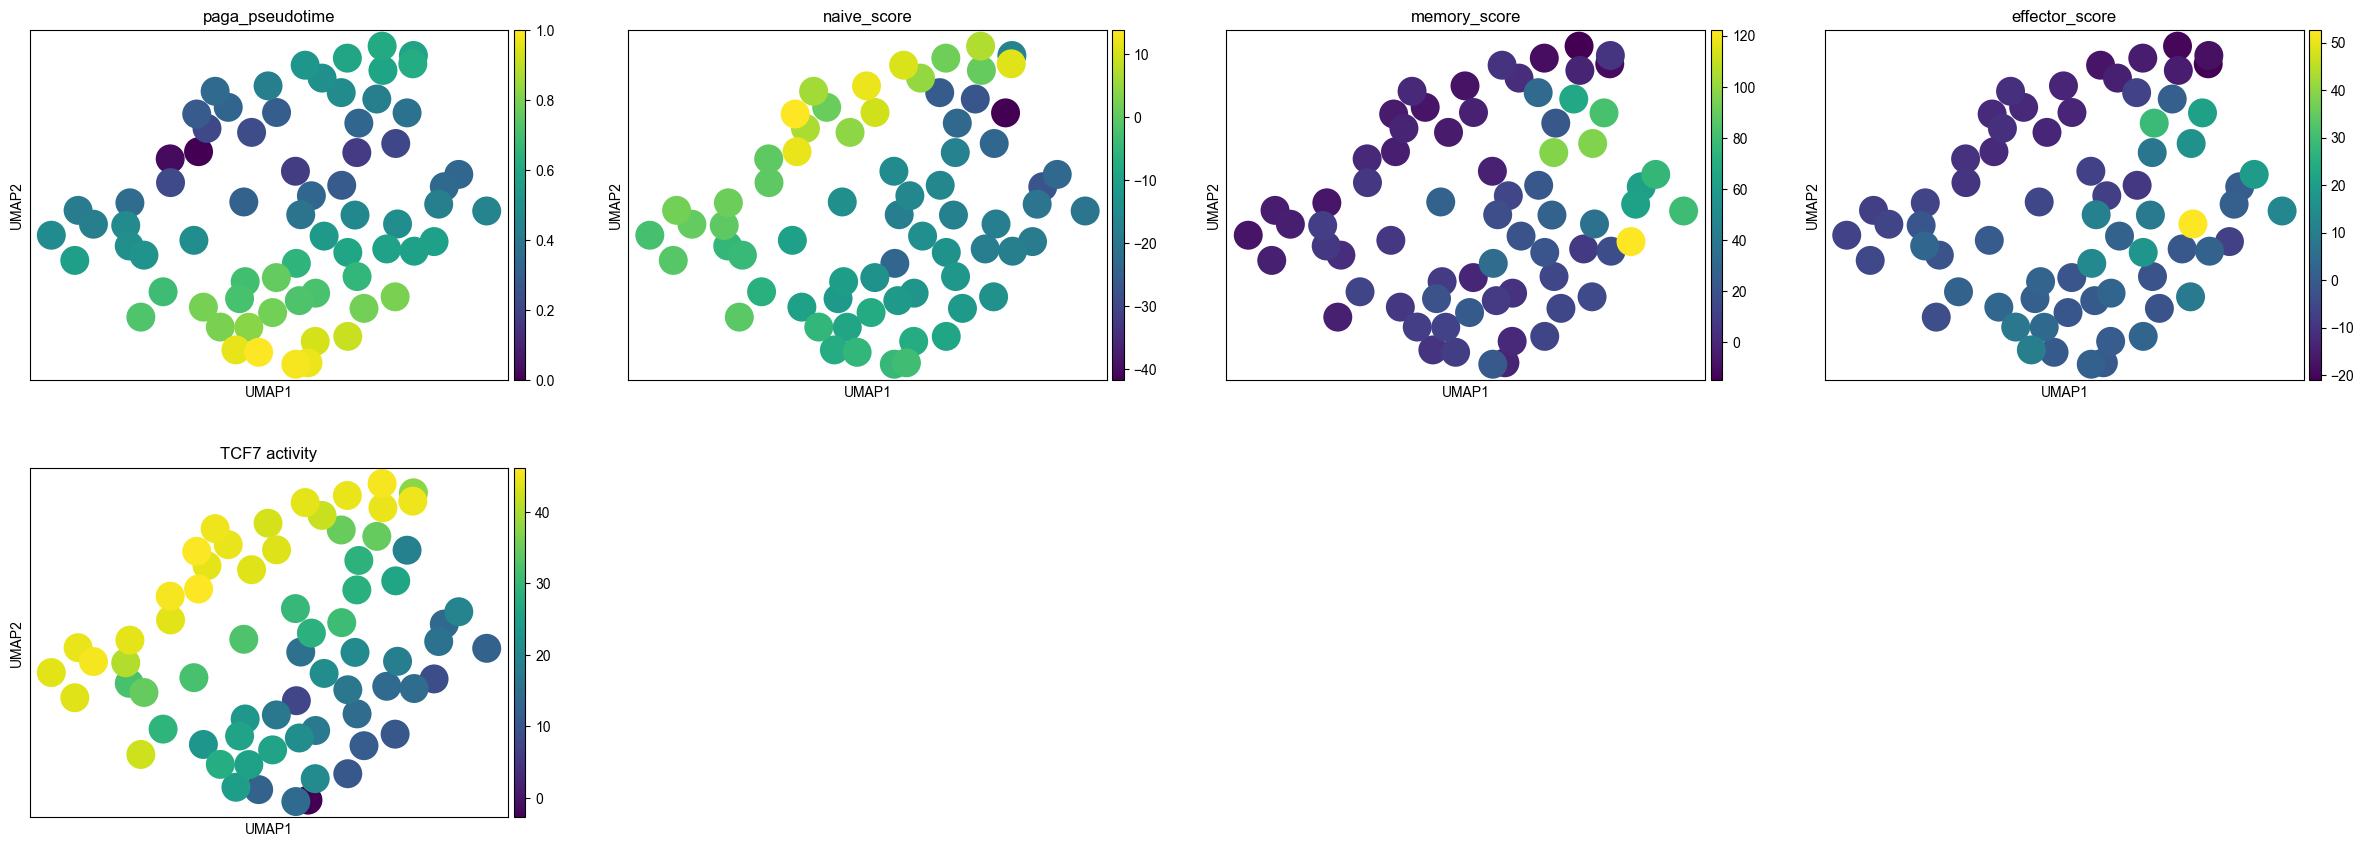

In [ ]:
tf = 'TCF7'
# only show for one group condition
unique_groups = adata_cluster.obs['group_id'].unique()
adata_plot = adata_cluster[adata_cluster.obs['group_id'] == unique_groups[0]]
assert tf in adata_plot.obsm['score_ulm'].columns, f"{tf} not found in ULM scores."
adata_plot.obs[f'{tf} activity'] = adata_plot.obsm['score_ulm'][tf]
sc.pp.neighbors(adata_plot, n_neighbors=15)
sc.tl.umap(adata_plot)
sc.pl.umap(adata_plot, color=['paga_pseudotime'] + [f'{subtype}_score' for subtype in markers.keys()] + [f'{tf} activity'])

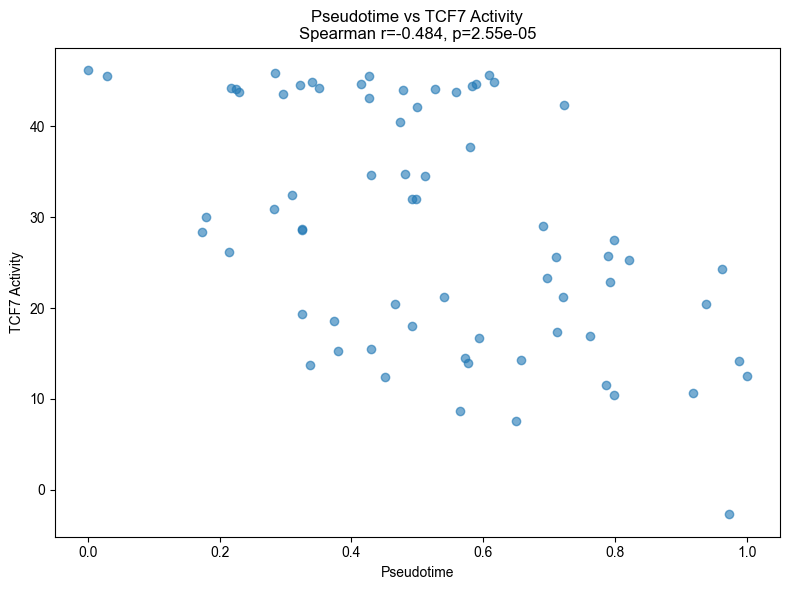

Spearman correlation: -0.484
P-value: 2.55e-05


In [ ]:
from scipy.stats import spearmanr

# Display pseudotime and TF activity in a scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata_plot.obs['paga_pseudotime'], adata_plot.obs[f'{tf} activity'], alpha=0.6)

# Calculate Spearman correlation
corr, pval = spearmanr(adata_plot.obs['paga_pseudotime'], adata_plot.obs[f'{tf} activity'])

ax.set_xlabel('Pseudotime')
ax.set_ylabel(f'{tf} Activity')
ax.set_title(f'Pseudotime vs {tf} Activity\nSpearman r={corr:.3f}, p={pval:.2e}')
plt.tight_layout()
plt.show()

print(f'Spearman correlation: {corr:.3f}')
print(f'P-value: {pval:.2e}')